In [60]:
import torch
import re
import adabmDCA 

from adabmDCA.fasta import get_tokens, write_fasta
from adabmDCA.io import load_params, load_chains, import_from_fasta
from adabmDCA.utils import init_parameters, init_chains, get_device, get_dtype
from adabmDCA.functional import one_hot
from adabmDCA.statmech import compute_energy

import matplotlib.pyplot as plt
import numpy as np


from scipy import stats
from sklearn.decomposition import PCA

In [17]:
def read_txt_to_tensor(file_path):
    with open(file_path, 'r') as f:
        data = [float(line.strip()) for line in f]
    
    tensor_data = torch.tensor(data, dtype=torch.float32)
    return tensor_data

def extract_fasta_tensors(file_path):
    # Liste per memorizzare i valori di energia e seq divergence
    energies = []
    seq_divergences = []

    # Leggere il file
    with open(file_path, "r") as f:
        for line in f:
            if line.startswith(">"):  # Le informazioni sono nelle righe con ">"
                match = re.search(r"DCAenergy ([\d\.]+) \| normalized seq. divergence ([\d\.]+)", line)
                if match:
                    energy = float(match.group(1))
                    seq_divergence = float(match.group(2))
                    energies.append(energy)
                    seq_divergences.append(seq_divergence)

    # Convertiamo le liste in tensori PyTorch
    energy_tensor = torch.tensor(energies, dtype=torch.float32)
    seq_divergence_tensor = torch.tensor(seq_divergences, dtype=torch.float32)
    
    return energy_tensor, seq_divergence_tensor

def compute_seqID(a1: torch.Tensor, single_seq: torch.Tensor):
    """
    Computes the Hamming distance 
    between a set of one-hot encoded sequences and a single one-hot encoded sequence.

    Args:
        a1 (torch.Tensor): Sequence dataset, shape (N, L, C), where N is the number of sequences,
                           L is the length, and C is the number of categories (one-hot size).
        single_seq (torch.Tensor): Single one-hot encoded sequence, shape (L, C).

    Returns:
        torch.Tensor: Hamming distances for each sequence in the dataset.
    """
    # print(a1.shape, single_seq.shape)
    a1 = a1.view(a1.shape[0], -1)
    single_seq = single_seq.view(1, -1)
    # print(a1.shape, single_seq.shape)
    seqID = (a1 * single_seq).sum(1) 

    return seqID


In [5]:
# Set the device
device = get_device("cpu")
dtype = get_dtype("float32")

Running on CPU


In [ ]:
tokens = get_tokens('protein')
params = load_params("density=0.125_params.dat", tokens=tokens, device=device, dtype=dtype)

# read in the data
batch1 = load_chains("batch1.fasta", tokens)
batch2 = load_chains("batch2.fasta", tokens)
batch3 = load_chains("batch3.fasta", tokens)
_, nat_data = import_from_fasta("../data/Chorismate_Mutase/CM_130530_MC.fasta", tokens=tokens, filter_sequences=True)
sample = load_chains("density=0.125_samples.fasta", tokens)
M_sanple, L, q = len(sample), len(sample[0]), len(tokens)
M_batch, L, q = len(batch1), len(batch1[0]), len(tokens)

# transform data to one-hot encoding
batch1 = one_hot(torch.tensor(batch1, device=device, dtype=torch.int32), num_classes=q).to(dtype)
batch2 = one_hot(torch.tensor(batch2, device=device, dtype=torch.int32), num_classes=q).to(dtype)
batch3 = one_hot(torch.tensor(batch3, device=device, dtype=torch.int32), num_classes=q).to(dtype)
nat_data = one_hot(torch.tensor(nat_data, device=device, dtype=torch.int32), num_classes=q).to(dtype)
sample = one_hot(torch.tensor(sample, device=device, dtype=torch.int32), num_classes=q).to(dtype)

Unknown token found: removing sequence gi|297170754|gb|ADI21776.1| hypothetical protein [uncultured gamma proteobacterium HF0130_22O14]


In [50]:
energies1, divergence1 = extract_fasta_tensors("batch1.fasta")
energies2, divergence2 = extract_fasta_tensors("batch2.fasta")
energies3, divergence3 = extract_fasta_tensors("batch3.fasta")

divergence = read_txt_to_tensor("divergence_values.txt")
energies = read_txt_to_tensor("energies.txt")

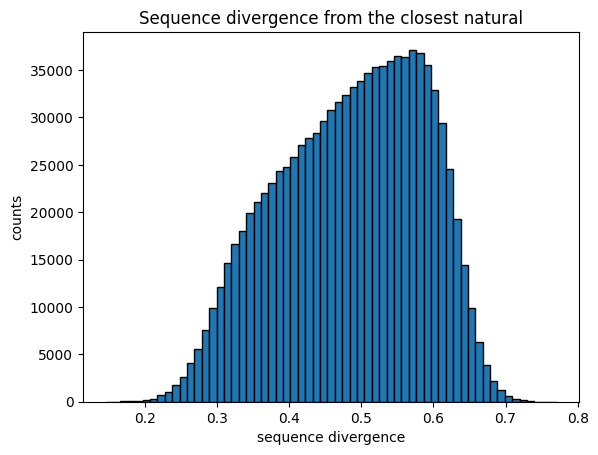

In [68]:
plt.hist(divergence, bins=61, edgecolor='black')

# Configurazione dell'istogramma
plt.title("Sequence divergence from the closest natural")
plt.xlabel("sequence divergence")
plt.ylabel("counts")

# Mostra il grafico
plt.savefig("plots/divergence_histogram.png")
plt.show()

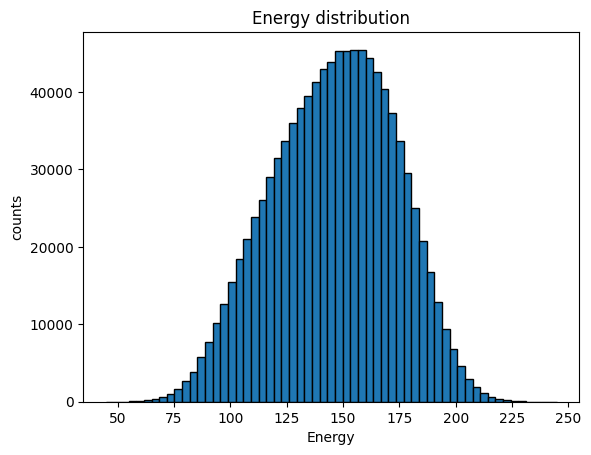

In [66]:
plt.hist(energies, bins=59, edgecolor='black')

# Configurazione dell'istogramma
plt.title("Energy distribution")
plt.xlabel("Energy")
plt.ylabel("counts")

# Mostra il grafico
plt.savefig("plots/energy_histogram.png")
plt.show()

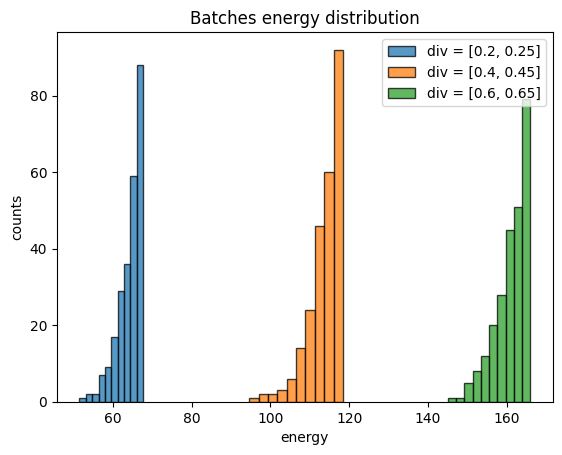

In [67]:
# Estrazione di 250 indici casuali

plt.hist(energies1, edgecolor='black', label="div = [0.2, 0.25]", alpha=0.75)
plt.hist(energies2, edgecolor='black', label="div = [0.4, 0.45]", alpha=0.75)
plt.hist(energies3, edgecolor='black', label="div = [0.6, 0.65]", alpha=0.75)

# Configurazione dell'istogramma
plt.title("Batches energy distribution")
plt.xlabel("energy")
plt.ylabel("counts")
plt.legend()
# Mostra il grafico
plt.savefig("plots/batches_energy_histogram.png")
plt.show()

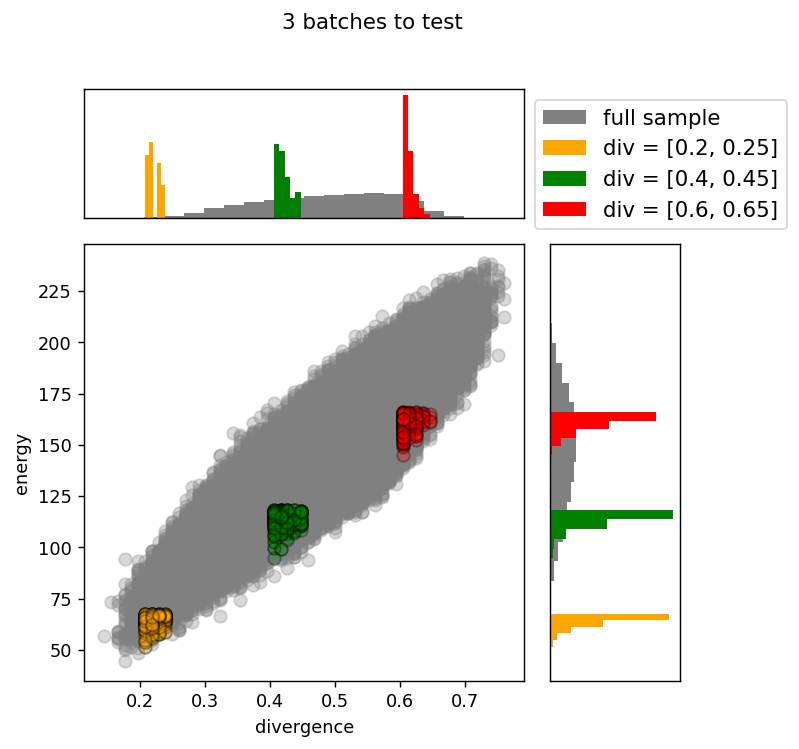

In [69]:
from matplotlib.gridspec import GridSpec

gs = GridSpec(4, 4)
title = "3 batches to test"
fig = plt.figure(figsize=(6, 6), dpi=128)
ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_hist_x = fig.add_subplot(gs[0, 0:3])
ax_hist_y = fig.add_subplot(gs[1:4, 3])
    
N1 = 250
N2 = 500_000
random_indices = torch.randperm(sample.size(0))[:N2] 
ax_scatter.scatter(divergence[random_indices], energies[random_indices], color='grey', s=50, label="full sample", zorder=0, alpha=0.3)
ax_scatter.scatter(divergence1, energies1, edgecolor='black', color='orange', s=50, label="div = [0.2, 0.25]", zorder=0, alpha=0.3)
ax_scatter.scatter(divergence2, energies2, edgecolor='black', color='green',  s=50, label="div = [0.6, 0.45]", zorder=0, alpha=0.3)
ax_scatter.scatter(divergence3, energies3, edgecolor='black', color='red',    s=50, label="div = [0.6, 0.65]", zorder=0, alpha=0.3)


ax_hist_x.hist(divergence[random_indices], bins=20, color='grey', label="full sample", zorder=0, weights=np.ones(N2)/N2, orientation='vertical', lw=1)
ax_hist_x.hist(divergence1, bins=5, color='orange', label="div = [0.2, 0.25]", zorder=0,  weights=np.ones(N1)/N1, orientation='vertical', lw=1)
ax_hist_x.hist(divergence2, bins=5, color='green',  label="div = [0.4, 0.45]", zorder=0,  weights=np.ones(N1)/N1, orientation='vertical', lw=1)
ax_hist_x.hist(divergence3, bins=5, color='red',    label="div = [0.6, 0.65]", zorder=0,  weights=np.ones(N1)/N1, orientation='vertical', lw=1)

ax_hist_y.hist(energies[random_indices], bins=20, color='grey', label="full sample", zorder=0, weights=np.ones(N2)/N2, orientation='horizontal', lw=1)
ax_hist_y.hist(energies1, bins=5, color='orange', label="div = [0.2, 0.25]", zorder=0, weights=np.ones(N1)/N1, orientation='horizontal', lw=1)
ax_hist_y.hist(energies2, bins=5, color='green',  label="div = [0.6, 0.45]", zorder=0, weights=np.ones(N1)/N1, orientation='horizontal', lw=1)
ax_hist_y.hist(energies3, bins=5, color='red',    label="div = [0.6, 0.65]", zorder=0, weights=np.ones(N1)/N1, orientation='horizontal', lw=1)


ax_scatter.set_xlabel(f"divergence")
ax_scatter.set_ylabel(f"energy")

fig.suptitle(title)
ax_hist_x.set_xticks([])
ax_hist_y.set_xticks([])
ax_hist_x.set_yticks([])
ax_hist_y.set_yticks([])

ax_hist_x.legend(fontsize=12, bbox_to_anchor=(1, 1))
plt.savefig("plots/energy_vs_divergence.png")

In [61]:
pca = PCA(n_components=4)
pca.fit(nat_data.view(nat_data.size(0), -1).cpu())
nat_data_pca = pca.transform(nat_data.view(nat_data.size(0), -1).cpu())
sample_pca = pca.transform(sample.view(sample.size(0), -1).cpu())

In [62]:
batch1_pca = pca.transform(batch1.view(batch1.size(0), -1).cpu())
batch2_pca = pca.transform(batch2.view(batch2.size(0), -1).cpu())
batch3_pca = pca.transform(batch3.view(batch3.size(0), -1).cpu())

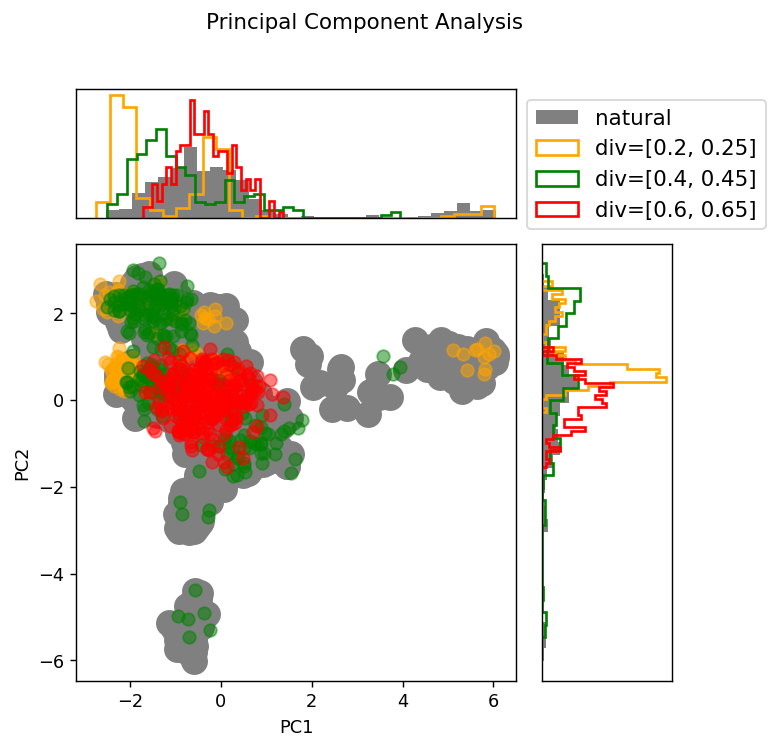

In [71]:
from matplotlib.gridspec import GridSpec


PC = [0, 1]

gs = GridSpec(4, 4)
title = "Principal Component Analysis"
fig = plt.figure(figsize=(6, 6), dpi=128)
ax_scatter = fig.add_subplot(gs[1:4, 0:3])
ax_hist_x = fig.add_subplot(gs[0, 0:3])
ax_hist_y = fig.add_subplot(gs[1:4, 3])
    
ax_scatter.scatter(nat_data_pca[:, PC[0]],     nat_data_pca[:, PC[1]],     color='grey',  s=200, zorder=0, alpha=1.0)
ax_scatter.scatter(batch1_pca[:, PC[0]], batch1_pca[:, PC[1]], color='orange',   s=50,  zorder=0, alpha=0.5)
ax_scatter.scatter(batch2_pca[:, PC[0]], batch2_pca[:, PC[1]], color='green',  s=50,  zorder=0, alpha=0.5)
ax_scatter.scatter(batch3_pca[:, PC[0]], batch3_pca[:, PC[1]], color='red', s=50,  zorder=0, alpha=0.5)


ax_hist_x.hist(nat_data_pca[:, PC[0]],     bins=30, color='grey',  label="natural",         zorder=0, density=True, orientation='vertical', lw=1)
ax_hist_x.hist(batch1_pca[:, PC[0]], bins=30, color='orange',   label="div=[0.2, 0.25]", zorder=1, density=True, orientation='vertical', lw=1.5, histtype='step')
ax_hist_x.hist(batch2_pca[:, PC[0]], bins=30, color='green',  label="div=[0.4, 0.45]", zorder=1, density=True, orientation='vertical', lw=1.5, histtype='step')
ax_hist_x.hist(batch3_pca[:, PC[0]], bins=30, color='red', label="div=[0.6, 0.65]", zorder=1, density=True, orientation='vertical', lw=1.5, histtype='step')

ax_hist_y.hist(nat_data_pca[:, PC[1]],     bins=30, color='grey',  zorder=0, density=True, orientation='horizontal', lw=1)
ax_hist_y.hist(batch1_pca[:, PC[1]], bins=30, color='orange',   zorder=1, density=True, orientation='horizontal', lw=1.5, histtype='step')
ax_hist_y.hist(batch2_pca[:, PC[1]], bins=30, color='green',  zorder=1, density=True, orientation='horizontal', lw=1.5, histtype='step')
ax_hist_y.hist(batch3_pca[:, PC[1]], bins=30, color='red', zorder=1, density=True, orientation='horizontal', lw=1.5, histtype='step')

ax_scatter.set_xlabel(f"PC{PC[0]+1}")
ax_scatter.set_ylabel(f"PC{PC[1]+1}")

fig.suptitle(title)
ax_hist_x.set_xticks([])
ax_hist_y.set_xticks([])
ax_hist_x.set_yticks([])
ax_hist_y.set_yticks([])

ax_hist_x.legend(fontsize=12, bbox_to_anchor=(1, 1))
plt.savefig("plots/PCA_12.png")